# Pap Smear Cytology Classification — ConvNeXt-Small

**Classes:** NILM (normal) · LSIL (mild abnormality) · HSIL (severe / precancerous)  
**Dataset:** Brown Multicellular ThinPrep Database — 200 images per class (600 total)  
**Split:** 60/20/20 train/val/test — matches the paper exactly (120 test images vs paper's 120)

**Why ConvNeXt-Small over ResNet50/EfficientNet:**
- Modernized CNN architecture (2022) using ViT design principles — depthwise convolutions, larger kernels, LayerNorm, GELU
- Consistently outperforms ResNet50 and EfficientNet on small medical imaging benchmarks
- Retains CNN inductive biases that are advantageous on small datasets like this one

## Cell 1 — Install dependencies

In [ ]:
!pip install -q torch torchvision torchmetrics scikit-learn matplotlib seaborn tqdm pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.7 MB/s eta 0:00:00


## Cell 2 — Mount Google Drive + global config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import torch

RAW_DATA_PATH = Path('/content/drive/MyDrive/BMT')

DATA_ROOT  = Path('/content/data')
RESULTS    = Path('/content/results/convnext_small')
EDA_OUT    = Path('/content/eda_outputs')
REPORT_OUT = Path('/content/report')

for p in [DATA_ROOT, RESULTS, EDA_OUT, REPORT_OUT]:
    p.mkdir(parents=True, exist_ok=True)

CLASSES     = ['NILM', 'LSIL', 'HSIL']
NUM_CLASSES = len(CLASSES)
SEED        = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device          : {DEVICE}')
print(f'Raw data exists : {RAW_DATA_PATH.exists()}')

Mounted at /content/drive
Device          : cuda
Raw data exists : True


## Cell 3 — Data setup (60/20/20 split)
Parses filenames (`HSIL (1).jpg`, `NIL (43).jpg`) and creates a stratified 60/20/20 train/val/test split — matching the paper exactly.  
Result: **120 train · 40 val · 40 test** per class.

In [ ]:
import random
import shutil
from collections import defaultdict

LABEL_MAP  = {'HSIL': 'HSIL', 'LSIL': 'LSIL', 'NIL': 'NILM'}
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
VAL_RATIO  = 0.20   # 60/20/20 — matches paper
TEST_RATIO = 0.20


def parse_label(filename):
    name = Path(filename).stem
    for raw in LABEL_MAP:
        if name.upper().startswith(raw):
            return LABEL_MAP[raw]
    return None


def build_split(src, dst, seed=42):
    if not src.exists():
        raise FileNotFoundError(f'Source not found: {src}')
    if dst.exists():
        shutil.rmtree(dst)

    by_class = defaultdict(list)
    unrecognized = []
    for f in sorted(src.iterdir()):
        if f.suffix.lower() not in IMG_EXTS:
            continue
        label = parse_label(f.name)
        if label is None: unrecognized.append(f.name)
        else: by_class[label].append(f)

    if unrecognized:
        print(f'⚠  {len(unrecognized)} unrecognized files skipped')

    print('\n── Found images ──────────────────────────────')
    for cls, files in sorted(by_class.items()):
        print(f'  {cls:<6}: {len(files)}')
    print(f'  Total : {sum(len(v) for v in by_class.values())}')

    rng = random.Random(seed)
    splits = {'train': {}, 'val': {}, 'test': {}}

    print('\n── Split sizes (60/20/20) ────────────────────')
    for cls, files in sorted(by_class.items()):
        rng.shuffle(files)
        n       = len(files)
        n_val   = max(1, round(n * VAL_RATIO))
        n_test  = max(1, round(n * TEST_RATIO))
        n_train = n - n_val - n_test
        splits['test'][cls]  = files[:n_test]
        splits['val'][cls]   = files[n_test:n_test+n_val]
        splits['train'][cls] = files[n_test+n_val:]
        print(f'  {cls:<6}: train={n_train}  val={n_val}  test={n_test}')

    total = 0
    for split_name, class_dict in splits.items():
        for cls, files in class_dict.items():
            out = dst / split_name / cls
            out.mkdir(parents=True, exist_ok=True)
            for i, src_f in enumerate(files):
                ext = src_f.suffix.lower()
                shutil.copy2(src_f, out / f'{cls}_{split_name}_{i+1:03d}{ext}')
                total += 1

    print(f'\n✓  {total} images copied to {dst}/')
    print(f'  {"Class":<8}  {"train":<8}  {"val":<8}  {"test":<8}')
    print('  ' + '-'*38)
    for cls in sorted(by_class):
        row = [len(list((dst/s/cls).iterdir())) for s in ['train','val','test']]
        print(f'  {cls:<8}  {row[0]:<8}  {row[1]:<8}  {row[2]:<8}')


build_split(RAW_DATA_PATH, DATA_ROOT, seed=SEED)


── Found images ──────────────────────────────
  HSIL  : 200
  LSIL  : 200
  NILM  : 200
  Total : 600

── Split sizes (60/20/20) ────────────────────
  HSIL  : train=120  val=40  test=40
  LSIL  : train=120  val=40  test=40
  NILM  : train=120  val=40  test=40

✓  600 images copied to /content/data/
  Class     train     val       test    
  --------------------------------------
  HSIL      120       40        40      
  LSIL      120       40        40      
  NILM      120       40        40      


## Cell 4 — Exploratory Data Analysis

  EDA — Pap Smear Classification

TRAIN (360 images)
  NILM  :  120  (33.3%)
  LSIL  :  120  (33.3%)
  HSIL  :  120  (33.3%)

VAL (120 images)
  NILM  :   40  (33.3%)
  LSIL  :   40  (33.3%)
  HSIL  :   40  (33.3%)

TEST (120 images)
  NILM  :   40  (33.3%)
  LSIL  :   40  (33.3%)
  HSIL  :   40  (33.3%)

Imbalance ratio (train): 1.00x
  → Balanced ✓

── Image size sample ─────────────────────────
  Width  : 1920 – 3264  (mean 2682)
  Height : 1080 – 1840  (mean 1511)


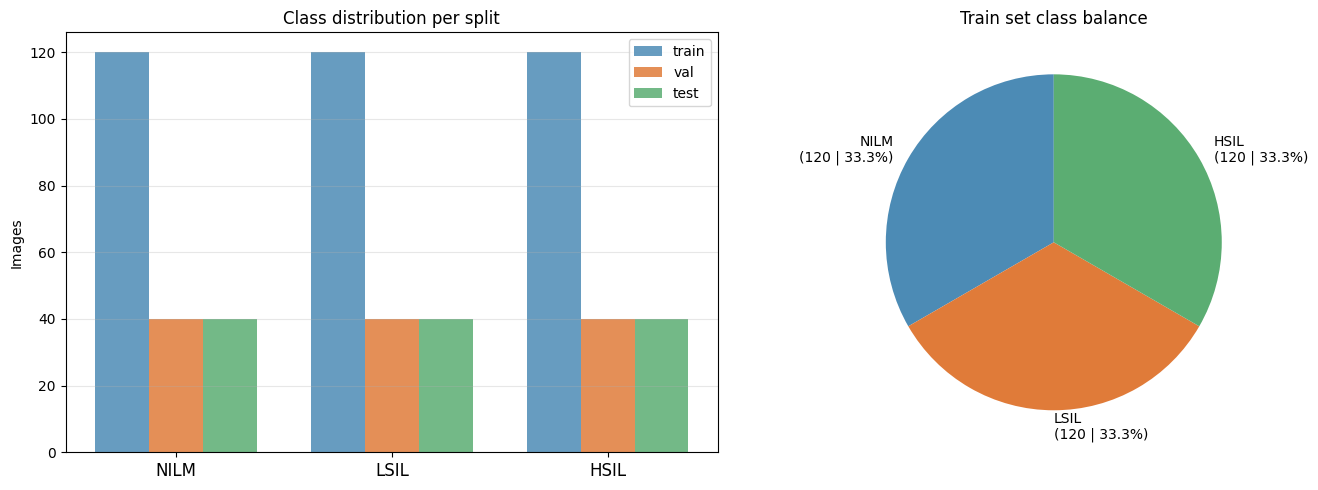

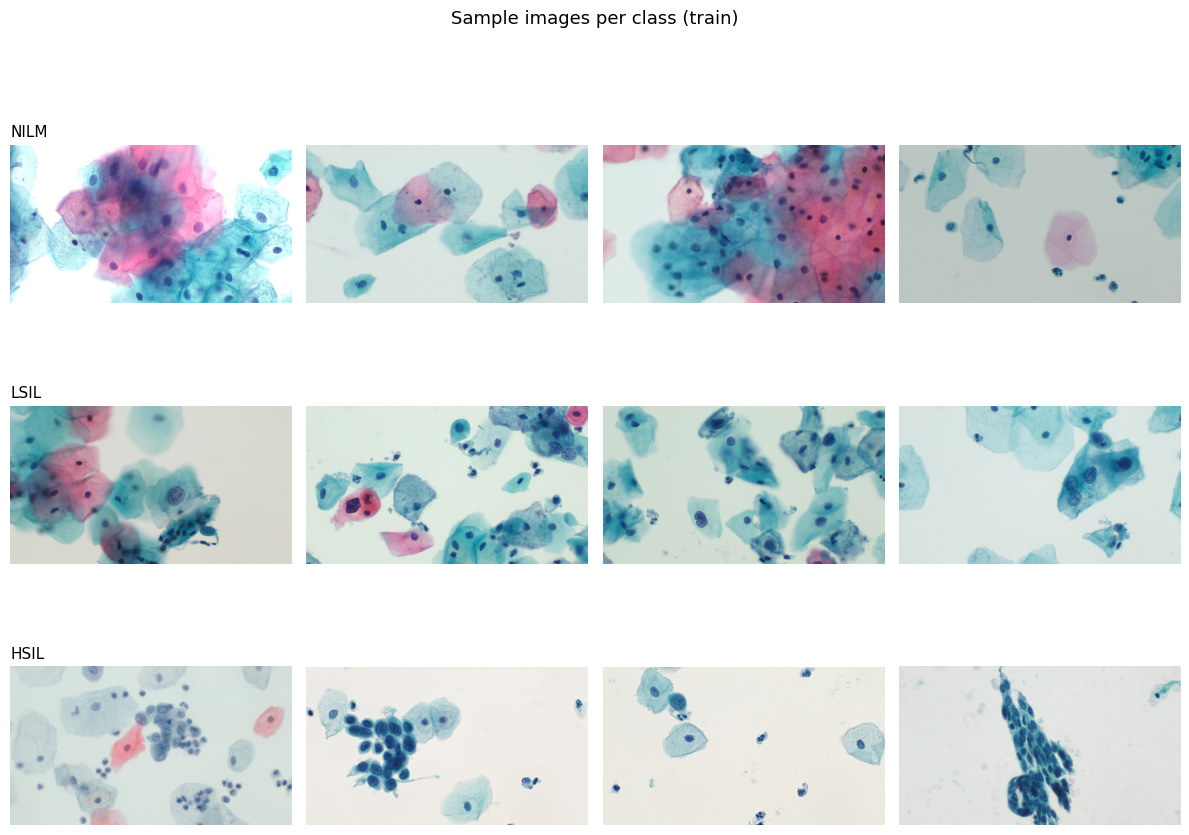

EDA plots saved to /content/eda_outputs/


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display


def count_samples(root):
    counts = {}
    for split in ['train', 'val', 'test']:
        counts[split] = {}
        for cls in CLASSES:
            p = root / split / cls
            imgs = list(p.glob('*.[jp][pn]g')) + list(p.glob('*.jpeg')) if p.exists() else []
            counts[split][cls] = len(imgs)
    return counts


counts = count_samples(DATA_ROOT)

print('='*52)
print('  EDA — Pap Smear Classification')
print('='*52)
for split, cls_counts in counts.items():
    total = sum(cls_counts.values())
    print(f'\n{split.upper()} ({total} images)')
    for cls in CLASSES:
        n = cls_counts[cls]
        print(f'  {cls:<6}: {n:>4}  ({100*n/max(total,1):.1f}%)')

train_vals = [counts['train'][c] for c in CLASSES]
ratio = max(train_vals) / max(min(train_vals), 1)
print(f'\nImbalance ratio (train): {ratio:.2f}x')
print('  → Balanced ✓' if ratio <= 1.5 else '  → Class weights will be applied')

# Image size check
print('\n── Image size sample ─────────────────────────')
widths, heights = [], []
for cls in CLASSES:
    for p in list((DATA_ROOT/'train'/cls).glob('*.[jp][pn]g'))[:10]:
        try:
            with Image.open(p) as im: widths.append(im.width); heights.append(im.height)
        except: pass
if widths:
    print(f'  Width  : {min(widths)} – {max(widths)}  (mean {np.mean(widths):.0f})')
    print(f'  Height : {min(heights)} – {max(heights)}  (mean {np.mean(heights):.0f})')

# Class distribution plot
bar_colors = ['#4C8BB5', '#E07B39', '#5BAD72']
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(CLASSES)); w = 0.25
for i, (split, color) in enumerate(zip(['train','val','test'], bar_colors)):
    vals = [counts[split][c] for c in CLASSES]
    axes[0].bar(x + i*w, vals, w, label=split, color=color, alpha=0.85)
axes[0].set_xticks(x+w); axes[0].set_xticklabels(CLASSES, fontsize=12)
axes[0].set_ylabel('Images'); axes[0].set_title('Class distribution per split')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
tv = [counts['train'][c] for c in CLASSES]; tot = sum(tv)
axes[1].pie(tv, labels=[f'{c}\n({v} | {v/tot*100:.1f}%)' for c,v in zip(CLASSES,tv)],
            colors=bar_colors, startangle=90)
axes[1].set_title('Train set class balance')
plt.tight_layout()
plt.savefig(EDA_OUT/'class_distribution.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# Sample grid
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, 9))
fig.suptitle('Sample images per class (train)', fontsize=13, y=1.01)
for row, cls in enumerate(CLASSES):
    imgs = list((DATA_ROOT/'train'/cls).glob('*.[jp][pn]g'))[:4]
    for col in range(4):
        ax = axes[row][col]; ax.axis('off')
        if col < len(imgs):
            try: ax.imshow(Image.open(imgs[col]).convert('RGB'))
            except: pass
        if col == 0: ax.set_title(cls, fontsize=11, loc='left')
plt.tight_layout()
plt.savefig(EDA_OUT/'sample_grid.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()
print(f'EDA plots saved to {EDA_OUT}/')

## Cell 5 — ConvNeXt-Small training

**Architecture:** ConvNeXt-Small pretrained on ImageNet-1K  
**Stage 1 (epochs 1–8):** Only the classifier head is trained (backbone frozen)  
**Stage 2 (epochs 9–60):** Full model fine-tuned at a lower learning rate  
**Key extras:** Mixup augmentation · label smoothing · cosine LR · weighted sampler · gradient clipping

In [ ]:
import json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models, transforms
from torchmetrics import Accuracy, F1Score, AUROC
from tqdm.notebook import tqdm

torch.manual_seed(SEED); np.random.seed(SEED)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_EPOCHS     = 70
LR_HEAD        = 3e-4      # phase 1: head only
LR_BACKBONE    = 1e-5      # phase 2: backbone (10x lower than before — fixes nan)
LR_HEAD_FT     = 5e-5      # phase 2: head during fine-tune
WARMUP_EPOCHS  = 3         # linear warmup after unfreeze before cosine kicks in
UNFREEZE_EPOCH = 8
LABEL_SMOOTH   = 0.1
MIXUP_ALPHA    = 0.3
GRAD_CLIP      = 0.5       # tighter clipping during unfreeze phase
TTA_RUNS       = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ────────────────────────────────────────────────────────────────
# RandomErasing and ElasticTransform help LSIL which sits between normal/precancerous
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ElasticTransform(alpha=50.0, sigma=5.0),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
tta_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Mixup ─────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred, y_a) + (1-lam)*criterion(pred, y_b)

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(DATA_ROOT/'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_ROOT/'val',   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_ROOT/'test',  transform=val_tf)

labels       = [s[1] for s in train_ds.samples]
class_counts = np.bincount(labels)
sample_wts   = 1.0 / class_counts[labels]
sampler      = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

loss_weights = torch.tensor(1.0/class_counts, dtype=torch.float).to(DEVICE)
loss_weights = loss_weights / loss_weights.sum() * NUM_CLASSES

print(f'Class mapping  : {train_ds.class_to_idx}')
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
print(f'Samples per class (train): {class_counts}')

# ── Model ─────────────────────────────────────────────────────────────────────
weights = models.ConvNeXt_Small_Weights.IMAGENET1K_V1
model   = models.convnext_small(weights=weights)
in_feat = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_feat, NUM_CLASSES)
for name, p in model.named_parameters():
    if 'classifier' not in name:
        p.requires_grad = False
model = model.to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
active = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {total:,} total  |  {active:,} trainable (head only)')

# ── Optimizer / scheduler ─────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
scaler    = torch.amp.GradScaler(enabled=DEVICE.type=='cuda')

# ── Training helpers ──────────────────────────────────────────────────────────
def train_one_epoch(model, loader):
    model.train()
    loss_sum = correct = total = 0
    for imgs, lbls in tqdm(loader, desc='  train', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        imgs, y_a, y_b, lam = mixup_data(imgs, lbls, MIXUP_ALPHA)
        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                            enabled=DEVICE.type=='cuda'):
            logits = model(imgs)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        if torch.isnan(loss):
            print('NaN loss detected — skipping batch')
            continue
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item()*lbls.size(0)
        correct  += (logits.argmax(1)==lbls).sum().item()
        total    += lbls.size(0)
    return (loss_sum/total if total else float('nan')), (correct/total if total else 0)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum = correct = total = 0
    all_probs, all_preds, all_lbls = [], [], []
    for imgs, lbls in tqdm(loader, desc='  eval', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, lbls)
        probs  = torch.softmax(logits, 1)
        preds  = logits.argmax(1)
        loss_sum += loss.item()*lbls.size(0)
        correct  += (preds==lbls).sum().item()
        total    += lbls.size(0)
        all_probs.append(probs.cpu()); all_preds.append(preds.cpu()); all_lbls.append(lbls.cpu())
    return loss_sum/total, correct/total, torch.cat(all_probs), torch.cat(all_preds), torch.cat(all_lbls)


# ── Training loop ─────────────────────────────────────────────────────────────
best_val_f1 = 0.0
history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
unfrozen = False

print(f'\n{"="*60}')
print(f'  Training ConvNeXt-Small  ({NUM_EPOCHS} epochs)')
print(f'{"="*60}')

for epoch in range(1, NUM_EPOCHS+1):

    # ── Phase 2: discriminative LRs — backbone much lower than head ───────────
    if epoch == UNFREEZE_EPOCH and not unfrozen:
        backbone_params = [p for n,p in model.named_parameters() if 'classifier' not in n]
        head_params     = [p for n,p in model.named_parameters() if 'classifier' in n]
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': LR_BACKBONE},
            {'params': head_params,     'lr': LR_HEAD_FT},
        ], weight_decay=1e-4)
        for p in model.parameters(): p.requires_grad = True
        def lr_lambda(ep):
            if ep < WARMUP_EPOCHS: return (ep + 1) / WARMUP_EPOCHS
            progress = (ep - WARMUP_EPOCHS) / max(NUM_EPOCHS - UNFREEZE_EPOCH - WARMUP_EPOCHS, 1)
            return 0.5 * (1 + np.cos(np.pi * progress))
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
        unfrozen = True
        print(f'  → Backbone unfrozen at epoch {epoch}')
        print(f'    backbone LR={LR_BACKBONE}  head LR={LR_HEAD_FT}  ({WARMUP_EPOCHS}-ep warmup)')

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc, vl_probs, vl_preds, vl_lbls = evaluate(model, val_loader)
    scheduler.step()

    if np.isnan(tr_loss) or np.isnan(vl_loss):
        print(f'Ep {epoch:02d}/{NUM_EPOCHS}  ⚠  NaN detected — skipping epoch')
        continue

    vl_f1 = F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro')(
        vl_preds, vl_lbls).item()

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

    star = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), RESULTS/'best_model.pth')
        star = '  ★ best'

    print(f'Ep {epoch:02d}/{NUM_EPOCHS}  '
          f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.3f}  '
          f'vl_f1={vl_f1:.4f}  ({time.time()-t0:.0f}s){star}')

print(f'\nBest val F1: {best_val_f1:.4f}  — checkpoint saved')

Class mapping  : {'HSIL': 0, 'LSIL': 1, 'NILM': 2}
Train: 360  Val: 120  Test: 120
Samples per class (train): [120 120 120]
Parameters: 49,456,995 total  |  3,843 trainable (head only)

  Training ConvNeXt-Small  (70 epochs)


  train:   0%|          | 0/12 [00:00<?, ?it/s]

  eval:   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/70  tr_loss=1.1215  tr_acc=0.311  vl_loss=1.0543  vl_acc=0.458  vl_f1=0.4035  (45s)  ★ best


  train:   0%|          | 0/12 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/4 [00:00<?, ?it/s]

Ep 69/70  tr_loss=0.5867  tr_acc=0.681  vl_loss=0.4700  vl_acc=0.908  vl_f1=0.9073  (44s)


  train:   0%|          | 0/12 [00:00<?, ?it/s]

  eval:   0%|          | 0/4 [00:00<?, ?it/s]

Ep 70/70  tr_loss=0.5943  tr_acc=0.658  vl_loss=0.4700  vl_acc=0.908  vl_f1=0.9073  (44s)

Best val F1: 0.9252  — checkpoint saved


## Cell 6 — Evaluation (standard + TTA + ROC curves)

  eval:   0%|          | 0/4 [00:00<?, ?it/s]


----------------------------------------------------  [TEST (STANDARD)]
  Accuracy   : 0.8833  (88.33%)
  Macro F1   : 0.8851
  AUC-ROC    : 0.9830
  F1 NILM   : 0.9333
  F1 LSIL   : 0.8750
  F1 HSIL   : 0.8471

              precision    recall  f1-score   support

        NILM     1.0000    0.8750    0.9333        40
        LSIL     0.8750    0.8750    0.8750        40
        HSIL     0.8000    0.9000    0.8471        40

    accuracy                         0.8833       120
   macro avg     0.8917    0.8833    0.8851       120
weighted avg     0.8917    0.8833    0.8851       120



  TTA 1/5:   0%|          | 0/4 [00:00<?, ?it/s]

  TTA 2/5:   0%|          | 0/4 [00:00<?, ?it/s]

  TTA 3/5:   0%|          | 0/4 [00:00<?, ?it/s]

  TTA 4/5:   0%|          | 0/4 [00:00<?, ?it/s]

  TTA 5/5:   0%|          | 0/4 [00:00<?, ?it/s]


----------------------------------------------------  [TEST (TTA)]
  Accuracy   : 0.8667  (86.67%)
  Macro F1   : 0.8675
  AUC-ROC    : 0.9809
  F1 NILM   : 0.8947
  F1 LSIL   : 0.8608
  F1 HSIL   : 0.8471

              precision    recall  f1-score   support

        NILM     0.9444    0.8500    0.8947        40
        LSIL     0.8718    0.8500    0.8608        40
        HSIL     0.8000    0.9000    0.8471        40

    accuracy                         0.8667       120
   macro avg     0.8721    0.8667    0.8675       120
weighted avg     0.8721    0.8667    0.8675       120



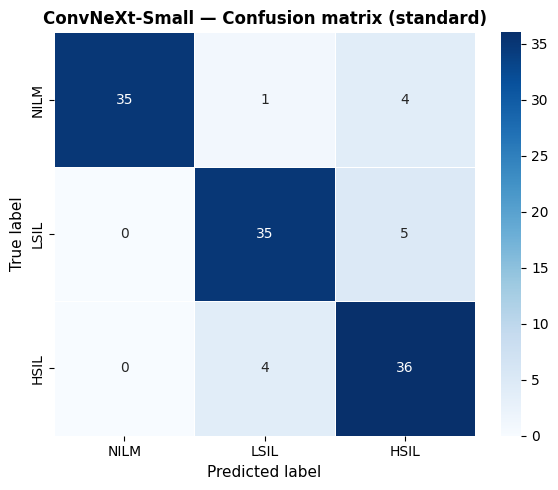

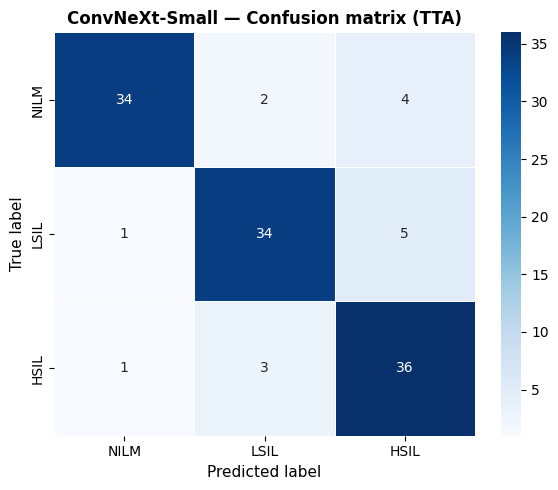

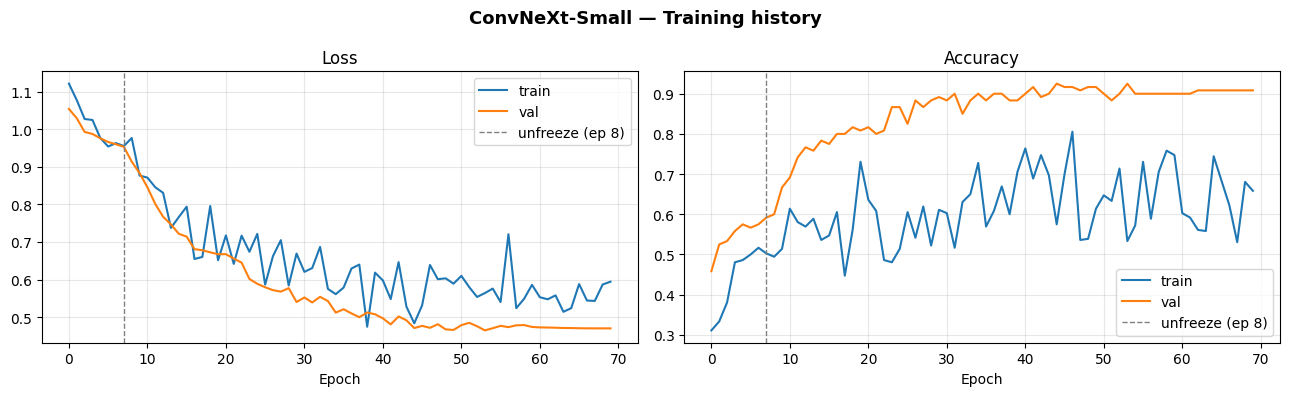

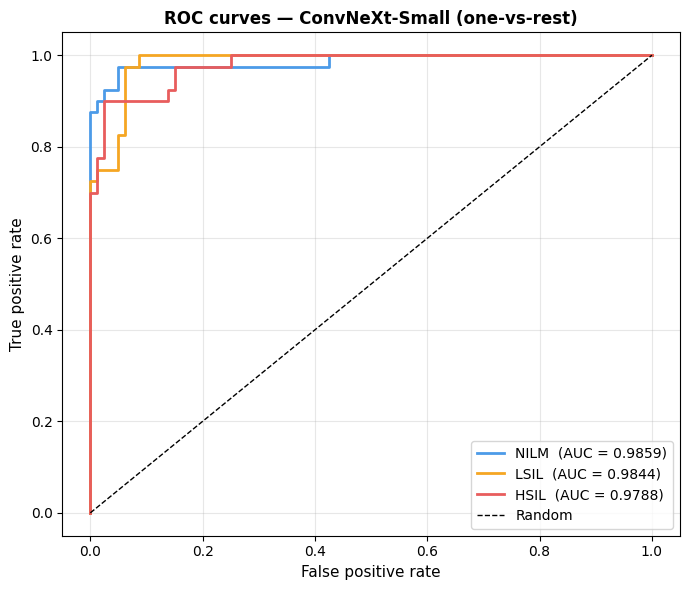


  FINAL RESULTS
  Standard  |  Acc: 0.8833  F1: 0.8851  AUC: 0.9830
  With TTA   |  Acc: 0.8667  F1: 0.8675  AUC: 0.9809
  Paper ResNet50 baseline: Acc: 0.7416


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc as sk_auc
from sklearn.preprocessing import label_binarize
from IPython.display import display

model.load_state_dict(torch.load(RESULTS/'best_model.pth', map_location=DEVICE))


def compute_metrics(probs, preds, labels, tag='test'):
    acc      = Accuracy(task='multiclass', num_classes=NUM_CLASSES)(preds, labels).item()
    f1_macro = F1Score(task='multiclass',  num_classes=NUM_CLASSES, average='macro')(preds, labels).item()
    f1_per   = F1Score(task='multiclass',  num_classes=NUM_CLASSES, average='none')(preds, labels).tolist()
    auc      = AUROC(task='multiclass',    num_classes=NUM_CLASSES)(probs, labels).item()
    cm       = confusion_matrix(labels.numpy(), preds.numpy())
    report   = classification_report(labels.numpy(), preds.numpy(), target_names=CLASSES, digits=4)
    print(f'\n{"-"*52}  [{tag.upper()}]')
    print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Macro F1   : {f1_macro:.4f}')
    print(f'  AUC-ROC    : {auc:.4f}')
    for cls, s in zip(CLASSES, f1_per): print(f'  F1 {cls:<6} : {s:.4f}')
    print(f'\n{report}')
    return {'accuracy': round(acc,4), 'macro_f1': round(f1_macro,4), 'auc': round(auc,4),
            'f1_per_class': {c: round(s,4) for c,s in zip(CLASSES, f1_per)},
            'confusion_matrix': cm.tolist()}


@torch.no_grad()
def evaluate_tta(model, dataset, n_runs=TTA_RUNS):
    model.eval()
    orig_tf = dataset.transform; dataset.transform = tta_tf
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
    probs_sum = None; all_lbls = []
    for run in range(n_runs):
        rp, rl = [], []
        for imgs, lbls in tqdm(loader, desc=f'  TTA {run+1}/{n_runs}', leave=False):
            rp.append(torch.softmax(model(imgs.to(DEVICE)),1).cpu())
            if run == 0: rl.append(lbls)
        bp = torch.cat(rp)
        probs_sum = bp if probs_sum is None else probs_sum + bp
        if run == 0: all_lbls = torch.cat(rl)
    dataset.transform = orig_tf
    avg = probs_sum / n_runs
    return avg, avg.argmax(1), all_lbls


def plot_cm(cm_arr, title, path):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label',      fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    display(plt.gcf()); plt.close()


# Standard eval
_, _, ts_probs, ts_preds, ts_lbls = evaluate(model, test_loader)
metrics_std = compute_metrics(ts_probs, ts_preds, ts_lbls, 'test (standard)')

# TTA eval
tta_probs, tta_preds, tta_lbls = evaluate_tta(model, test_ds)
metrics_tta = compute_metrics(tta_probs, tta_preds, tta_lbls, 'test (TTA)')

# Save raw probs
np.save(RESULTS/'test_probs.npy',  ts_probs.numpy())
np.save(RESULTS/'test_labels.npy', ts_lbls.numpy())

# Confusion matrices
plot_cm(np.array(metrics_std['confusion_matrix']),
        'ConvNeXt-Small — Confusion matrix (standard)', RESULTS/'confusion_matrix.png')
plot_cm(np.array(metrics_tta['confusion_matrix']),
        'ConvNeXt-Small — Confusion matrix (TTA)', RESULTS/'confusion_matrix_tta.png')

# Training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key, title in zip(axes, ['loss','acc'], ['Loss','Accuracy']):
    ax.plot(history[f'train_{key}'], label='train', linewidth=1.5)
    ax.plot(history[f'val_{key}'],   label='val',   linewidth=1.5)
    ax.axvline(UNFREEZE_EPOCH-1, color='gray', linestyle='--', linewidth=1,
               label=f'unfreeze (ep {UNFREEZE_EPOCH})')
    ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('ConvNeXt-Small — Training history', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS/'training_history.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# ROC curves
labels_bin = label_binarize(ts_lbls.numpy(), classes=range(NUM_CLASSES))
fig, ax    = plt.subplots(figsize=(7, 6))
for i, (cls, color) in enumerate(zip(CLASSES, ['#4C9BE8','#F5A623','#E85D5D'])):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], ts_probs.numpy()[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls}  (AUC = {sk_auc(fpr,tpr):.4f})')
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_xlabel('False positive rate', fontsize=11)
ax.set_ylabel('True positive rate',  fontsize=11)
ax.set_title('ROC curves — ConvNeXt-Small (one-vs-rest)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS/'roc_curves.png', dpi=150, bbox_inches='tight')
display(plt.gcf()); plt.close()

# Save metrics JSON
def strip_cm(d): return {k:v for k,v in d.items() if k!='confusion_matrix'}
with open(RESULTS/'metrics.json','w') as f:
    json.dump({'standard': strip_cm(metrics_std), 'tta': strip_cm(metrics_tta)}, f, indent=2)

print(f'\n{"="*60}')
print('  FINAL RESULTS')
print(f'{"="*60}')
for tag, m in [('Standard', metrics_std), ('With TTA ', metrics_tta)]:
    print(f'  {tag}  |  Acc: {m["accuracy"]:.4f}  F1: {m["macro_f1"]:.4f}  AUC: {m["auc"]:.4f}')
print(f'  Paper ResNet50 baseline: Acc: 0.7416')